<a href="https://colab.research.google.com/github/joyjit-das/sof-tiu-ai-lab/blob/main/ai_lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Route from Delhi to Kolkata: EXISTS
Route from Delhi to Chennai: NO ROUTE

Connected Components Found:
 Group 1: Delhi, Lucknow, Varanasi, Kolkata, Jaipur
 Group 2: Mumbai, Bengaluru, Chennai, Pune


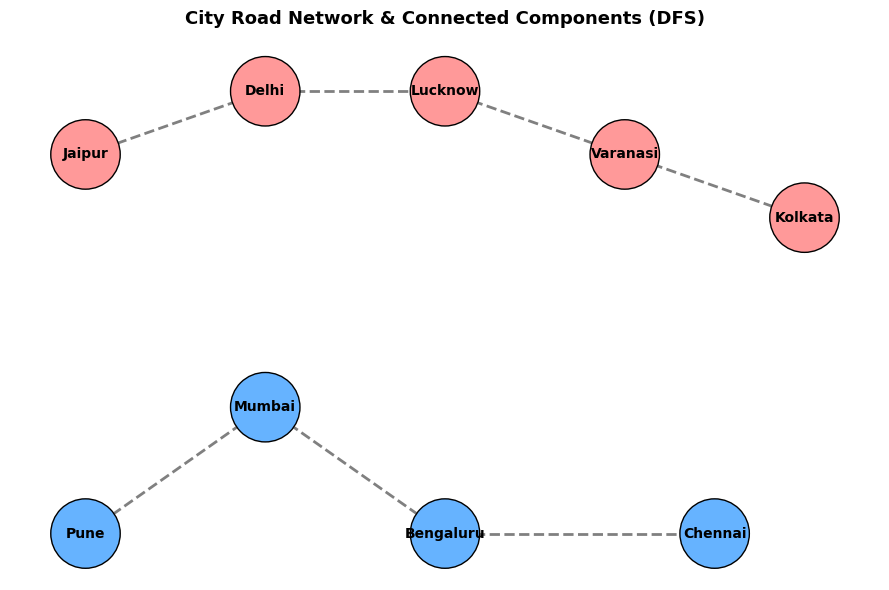

In [2]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. Road network adjacency list using standard city names
city_graph = {
    # Northern/Eastern Component
    'Delhi': ['Jaipur', 'Lucknow'],
    'Jaipur': ['Delhi'],
    'Lucknow': ['Delhi', 'Varanasi'],
    'Varanasi': ['Lucknow', 'Kolkata'],
    'Kolkata': ['Varanasi'],

    # Southern Component (Isolated sub-network)
    'Mumbai': ['Pune', 'Bengaluru'],
    'Pune': ['Mumbai'],
    'Bengaluru': ['Mumbai', 'Chennai'],
    'Chennai': ['Bengaluru']
}

# 2. Check if a route exists between two cities using DFS (Iterative)
def is_route_exist(graph, start_city, target_city):
    if start_city not in graph or target_city not in graph:
        return False

    visited = set()
    stack = [start_city]

    while len(stack) > 0:
        city = stack.pop()

        if city == target_city:
            return True

        if city not in visited:
            visited.add(city)
            for neighbor in graph[city]:
                if neighbor not in visited:
                    stack.append(neighbor)

    return False

# Helper function: Collect all cities reachable from a starting city
def dfs_collect_component(graph, start_city, visited):
    component = []
    stack = [start_city]

    while len(stack) > 0:
        city = stack.pop()
        if city not in visited:
            visited.add(city)
            component.append(city)
            for neighbor in graph[city]:
                if neighbor not in visited:
                    stack.append(neighbor)

    return component

# 3. Find all connected components in the graph
def find_connected_components(graph):
    visited = set()
    components = []

    for city in graph:
        if city not in visited:
            comp = dfs_collect_component(graph, city, visited)
            components.append(comp)

    return components

# --- Execution & Verification ---

# Test 1: Route existence
source_1, target_1 = 'Delhi', 'Kolkata'
source_2, target_2 = 'Delhi', 'Chennai'

print(f"Route from {source_1} to {target_1}:", "EXISTS" if is_route_exist(city_graph, source_1, target_1) else "NO ROUTE")
print(f"Route from {source_2} to {target_2}:", "EXISTS" if is_route_exist(city_graph, source_2, target_2) else "NO ROUTE")

# Test 2: Connected components
all_components = find_connected_components(city_graph)
print("\nConnected Components Found:")
for idx, comp in enumerate(all_components, start=1):
    print(f" Group {idx}: {', '.join(comp)}")

# 4. Visualization using Matplotlib and NetworkX
def visualize_city_graph(graph, components):
    G = nx.Graph(graph)

    # Assign custom colors to separate connected components visually
    colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
    node_color_map = {}

    for idx, comp in enumerate(components):
        color = colors[idx % len(colors)]
        for city in comp:
            node_color_map[city] = color

    color_list = [node_color_map[node] for node in G.nodes()]

    # Layout for clear visual separation of regions
    pos = {
        'Delhi': (-1, 1),
        'Jaipur': (-2, 0.5),
        'Lucknow': (0, 1),
        'Varanasi': (1, 0.5),
        'Kolkata': (2, 0),
        'Mumbai': (-1, -1.5),
        'Pune': (-2, -2.5),
        'Bengaluru': (0, -2.5),
        'Chennai': (1.5, -2.5)
    }

    plt.figure(figsize=(9, 6))

    # Draw graph elements
    nx.draw_networkx_edges(G, pos, width=2, edge_color='gray', style='dashed')
    nx.draw_networkx_nodes(G, pos, node_size=2500, node_color=color_list, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    plt.title("City Road Network & Connected Components (DFS)", fontsize=13, fontweight='bold', pad=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Render diagram
visualize_city_graph(city_graph, all_components)